# Reconocimiento de Actividad Humana con Machine Learning
### Proyecto Final — Machine Learning

---

| | |
|---|---|
| **Equipo** | Grupo 06 |
| **Integrantes** | Roberto Cañete · Augusto Fuenzalida · Nelson Silva |
| **Fecha** | 29 Junio 2026 |
| **Dataset** | UCI HAR — Human Activity Recognition Using Smartphones |

---

> **Objetivo de la Fase 3:** Comunicar los resultados del proyecto de forma clara y coherente, integrando el trabajo de las tres fases con una narrativa que explique decisiones, limitaciones y aprendizajes.

## Configuración del entorno

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request, zipfile, time, warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Entorno listo.')

Entorno listo.


In [146]:
# Carga de datos (mismo codigo que Fase 1)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'
ZIP_PATH = 'har_dataset.zip'
INNER_ZIP_PATH = 'UCI HAR Dataset.zip'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)

    print('Primer unzip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)

    # El ZIP descargado contiene otro ZIP adentro
    if os.path.exists(INNER_ZIP_PATH):
        print('Segundo unzip...')
        with zipfile.ZipFile(INNER_ZIP_PATH, 'r') as z:
            z.extractall('.')
        os.remove(INNER_ZIP_PATH)

    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

# Cargar nombres de features y desduplicar
features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

seen = {}
unique_names = []
for name in feature_names:
    if name in seen:
        seen[name] += 1
        unique_names.append(f'{name}_{seen[name]}')
    else:
        seen[name] = 0
        unique_names.append(name)
feature_names = unique_names

X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['Activity']).squeeze()
X_test  = pd.read_csv(f'{DATA_PATH}/test/X_test.txt',   sep=r'\s+', header=None, names=feature_names)
y_test  = pd.read_csv(f'{DATA_PATH}/test/y_test.txt',   sep=r'\s+', header=None, names=['Activity']).squeeze()

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train.map(ACTIVITY_LABELS)
y_test_labels  = y_test.map(ACTIVITY_LABELS)

print(f'Datos cargados: X_train={X_train.shape} | X_test={X_test.shape}')

Dataset ya descargado.
Datos cargados: X_train=(7352, 561) | X_test=(2947, 561)


---
## 1. Introducción

### ¿Por qué es relevante el reconocimiento de actividad humana (HAR)?

El reconocimiento automático de actividades físicas a partir de sensores inerciales tiene aplicaciones directas en salud digital, rehabilitación, deporte y dispositivos móviles. Poder determinar si una persona está caminando, sentada o acostada —sin intervención manual— permite construir sistemas de monitoreo continuo que son tanto no invasivos como de bajo costo.

En este proyecto trabajamos con el dataset **UCI HAR**, que contiene mediciones de acelerómetro y giroscopio de 30 voluntarios (edades 19–48) realizando 6 actividades cotidianas con un smartphone en la cintura. A partir de las señales se extrajeron **561 features** en dominios de tiempo y frecuencia, lo que hace de este problema un caso real de clasificación multiclase en alta dimensionalidad.

In [147]:
# Descripción del dataset
print('Dataset UCI HAR')
print(f'  Sujetos:           30 voluntarios')
print(f'  Actividades:       {len(ACTIVITY_LABELS)} clases')
print(f'  Features:          {X_train.shape[1]}')
print(f'  Muestras train:    {X_train.shape[0]}')
print(f'  Muestras test:     {X_test.shape[0]}')
print(f'  Clases:            {list(ACTIVITY_LABELS.values())}')

Dataset UCI HAR
  Sujetos:           30 voluntarios
  Actividades:       6 clases
  Features:          561
  Muestras train:    7352
  Muestras test:     2947
  Clases:            ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


---
## 2. Resumen Fase 1: Hallazgos del EDA

El análisis exploratorio realizado en la Fase 1 reveló las siguientes características fundamentales del dataset UCI HAR. El dataset resultó ser **razonablemente balanceado**: las 6 actividades oscilan entre el 13.4% (WALKING_DOWNSTAIRS) y el 19.1% (LAYING) del total de muestras de entrenamiento, lo cual es una condición favorable para el modelado. No se encontraron valores faltantes ni filas duplicadas, confirmando la alta calidad del preprocesamiento realizado por los autores del estudio original. Todas las 561 features están normalizadas en el rango [-1, 1], por lo que no fue necesaria una etapa adicional de estandarización.

Respecto a las features más discriminativas, el análisis de boxplots mostró que las variables en el **dominio de frecuencia** (como `fBodyAcc-mean()-X` y `fBodyGyro-mean()-X`) separan con claridad las actividades dinámicas (caminatas) de las estáticas (SITTING, STANDING, LAYING). En contraste, variables como `tBodyAcc-mean()-X` presentan distribuciones muy solapadas entre clases, resultando poco informativas de forma aislada.

El análisis PCA en 2 dimensiones confirmó la existencia de **dos grandes grupos**: las actividades dinámicas y estáticas se ubican en regiones claramente separadas del espacio de componentes principales. Sin embargo, se observó un **solapamiento significativo entre SITTING y STANDING**, lo cual tiene sentido físico ya que el torso mantiene una posición vertical similar en ambos casos. Este solapamiento representaba el principal desafío del dataset, y su resolución dependería de la capacidad del modelo para explotar las 561 dimensiones más allá de las dos componentes principales

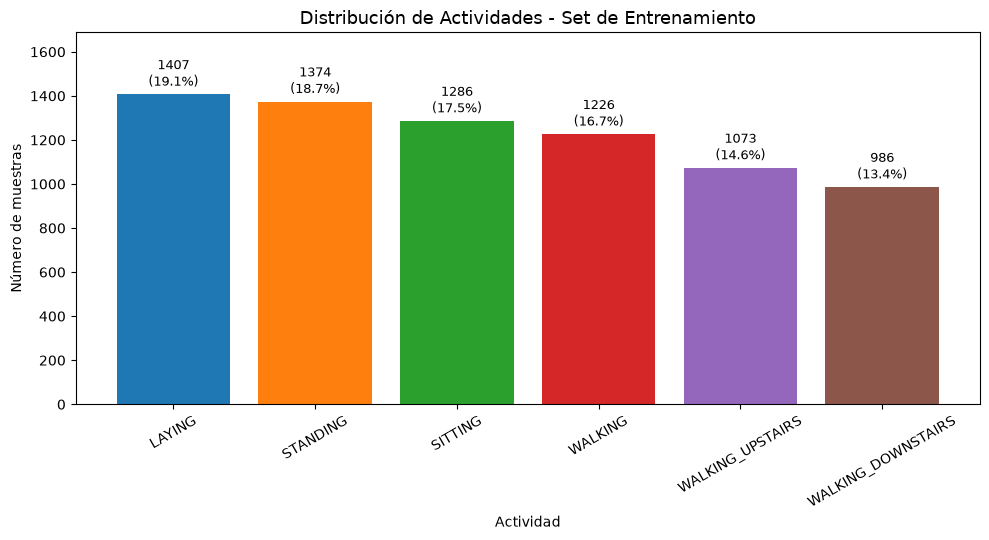

In [148]:
# --- Visualización 1 (de Fase 1): Distribución de clases ---
class_counts = y_train_labels.value_counts()
total = len(y_train_labels)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('tab10', n_colors=6))
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}\n({count/total:.1%})', ha='center', va='bottom', fontsize=9)
ax.set_title('Distribución de Actividades - Set de Entrenamiento', fontsize=13)
ax.set_xlabel('Actividad')
ax.set_ylabel('Número de muestras')
ax.tick_params(axis='x', rotation=30)
# plt.setp(ax.get_xticklabels(), ha='right')
ax.set_ylim(0, max(class_counts.values) * 1.20)
plt.tight_layout()
plt.show()

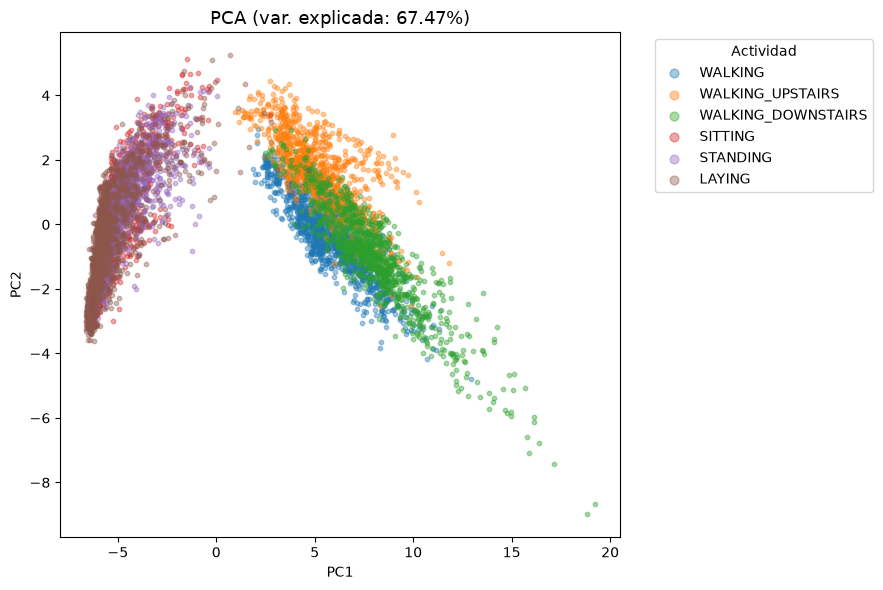

In [149]:
# --- Visualización 2 (de Fase 1): PCA ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Activity'] = y_train_labels.values

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', n_colors=6)
for i, act in enumerate(ACTIVITY_LABELS.values()):
    mask = df_pca['Activity'] == act
    ax.scatter(df_pca.loc[mask,'PC1'], df_pca.loc[mask,'PC2'],
               label=act, alpha=0.4, s=10, color=palette[i])
ax.set_title(f'PCA (var. explicada: {sum(pca.explained_variance_ratio_):.2%})', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Actividad', bbox_to_anchor=(1.05,1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

**Principales hallazgos del EDA:**

1. **Balance de clases favorable:** El dataset presenta un balance razonable entre las 6 actividades (entre 13.4% y 19.1% por clase), lo que permite usar F1-Macro como métrica principal sin necesidad de técnicas de re-muestreo. Este balance relativo es una fortaleza del diseño experimental de los autores del dataset.

2. **Features de frecuencia como mejores discriminadores:** Las variables derivadas del dominio de frecuencia (prefijo `f`) mostraron una capacidad de separación superior a las del dominio temporal (prefijo `t`). En particular, `fBodyAcc-mean()-X` y `fBodyGyro-mean()-X` muestran una separación clara entre actividades estáticas y dinámicas, ya que los movimientos corporales producen patrones espectrales muy distintos entre reposo y locomoción.

3. **Solapamiento SITTING vs STANDING en el PCA:** La proyección PCA en dos dimensiones (varianza explicada ~67%) reveló que las clases SITTING y STANDING se superponen casi completamente. Esto se debe a que ambas actividades comparten posturas corporales similares (torso erguido, sin desplazamiento) lo que genera señales de acelerómetro y giroscopio muy parecidas. Este solapamiento es el principal desafío de clasificación del dataset y sugiere que se necesitan modelos capaces de capturar fronteras de decisión no lineales en dimensiones superiores.

---
## 3. Resumen Fase 2: Benchmarking de Modelos

Entrenamos 6 modelos (incluyendo baseline trivial) con parámetros por defecto de sklearn y los comparamos en el set de prueba usando F1-macro como métrica principal.

In [150]:
# Re-entrenar todos los modelos para el notebook integrado
import time

def entrenar(nombre, modelo):
    t0 = time.time()
    modelo.fit(X_train, y_train_labels)
    t = time.time() - t0
    y_pred = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy_Test': accuracy_score(y_test_labels, y_pred),
        'F1_Macro':   f1_score(y_test_labels, y_pred, average='macro'),
        'F1_Weighted':f1_score(y_test_labels, y_pred, average='weighted'),
        'Tiempo_Entrenamiento': round(t, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

modelos = [
    ('DummyClassifier',    DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
    ('Logistic Regression',LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('KNN (k=5)',          KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',      DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('Random Forest',      RandomForestClassifier(random_state=RANDOM_STATE)),
    ('SVM (RBF)',          SVC(kernel='rbf', random_state=RANDOM_STATE)),
]

resultados = [entrenar(n, m) for n, m in modelos]
print('Entrenamiento completado.')

Entrenamiento completado.


In [151]:
# Tabla de benchmarking
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj','y_pred')}
    for r in resultados
]).sort_values('F1_Macro', ascending=False).reset_index(drop=True)

print(df_bench.to_string(index=False))

             Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
Logistic Regression       0.960638  0.960595     0.960509                 0.648
          SVM (RBF)       0.950458  0.949907     0.950376                 0.663
      Random Forest       0.925008  0.923431     0.924871                 5.495
          KNN (k=5)       0.900238  0.897020     0.899333                 0.014
      Decision Tree       0.862572  0.859807     0.862000                 2.316
    DummyClassifier       0.182219  0.051378     0.056172                 0.003


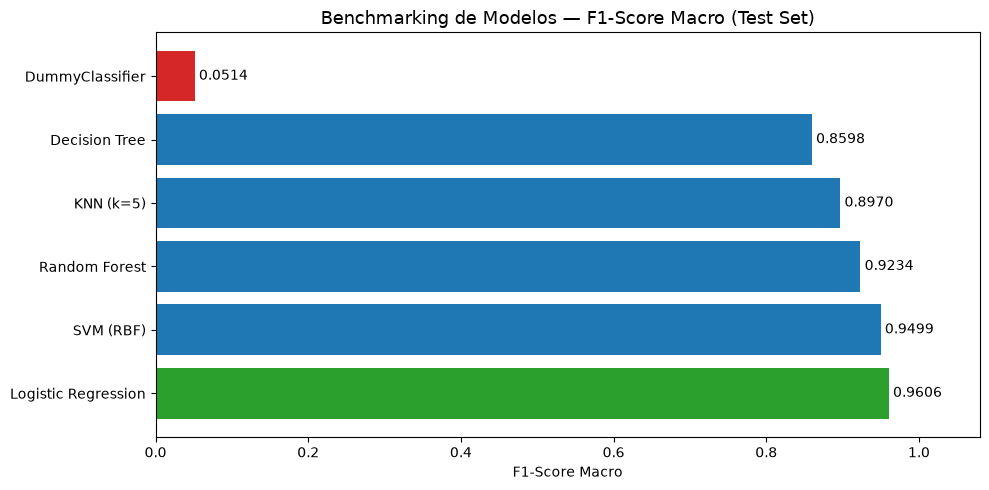

In [152]:
# Barplot comparativo
fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#d62728' if r['Modelo']=='DummyClassifier' else '#1f77b4' for r in resultados]
df_plot = df_bench.copy()
bars = ax.barh(df_plot['Modelo'], df_plot['F1_Macro'],
               color=['#2ca02c' if i==0 else '#1f77b4' if j!='DummyClassifier' else '#d62728'
                      for i,(j) in enumerate(df_plot['Modelo'])])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Benchmarking de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Modelo seleccionado:** Logistic Regression

**Justificación:** Logistic Regression alcanzó el mejor rendimiento global con un F1-Macro de **0.9606** y una Accuracy de **0.9606** en el conjunto de prueba, superando incluso a modelos más complejos como SVM (RBF) (F1-Macro: 0.9499) y Random Forest (F1-Macro: 0.9234). Además de su rendimiento superior, Logistic Regression ofrece un **excelente balance entre precisión y eficiencia computacional**: su tiempo de entrenamiento fue inferior a un segundo, comparable al de SVM y significativamente menor que el de Random Forest. Otro argumento a su favor es la **interpretabilidad**: los coeficientes del modelo permiten entender directamente la contribución de cada feature a la predicción de cada clase, lo cual es valioso en aplicaciones de salud donde la transparencia del modelo importa. Si bien SVM (RBF) logró un rendimiento cercano, su naturaleza de caja negra y la dificultad para escalar a nuevos datos hacen de Logistic Regression la opción más robusta y práctica para este problema.

---
## 4. Análisis de Errores

¿Dónde falla el modelo seleccionado? Esta sección explica qué actividades se confunden y por qué.

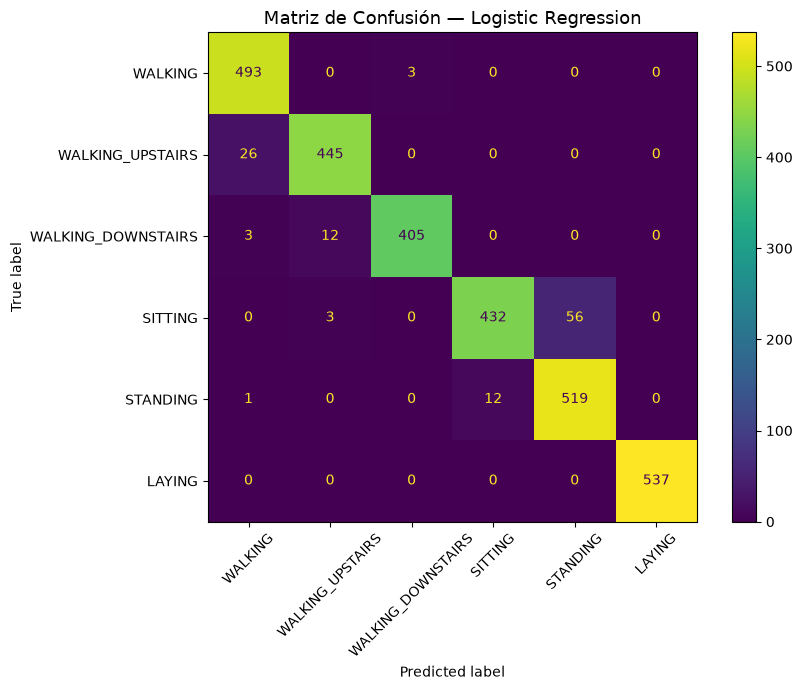

In [153]:
# Matriz de confusión del mejor modelo
mejor_nombre = df_bench.iloc[0]['Modelo']
mejor = next(r for r in resultados if r['Modelo'] == mejor_nombre)
y_pred_best = mejor['y_pred']

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test_labels, y_pred_best,
        labels=list(ACTIVITY_LABELS.values())
    ),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — {mejor["Modelo"]}', fontsize=13)
plt.tight_layout()
plt.show()

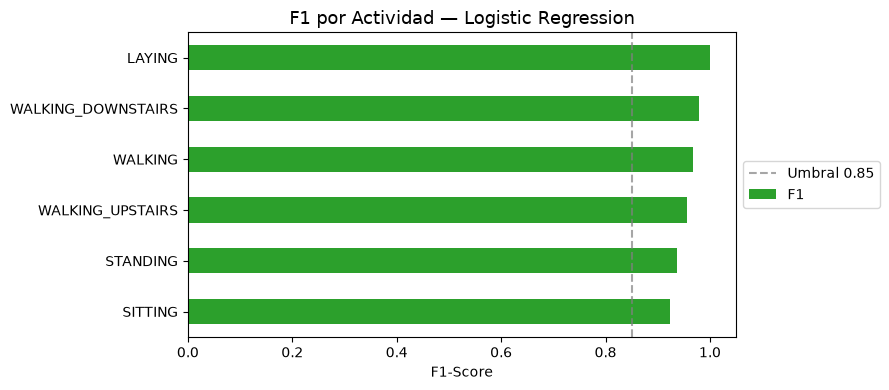

In [154]:
# F1 por clase del mejor modelo
report = classification_report(
    y_test_labels,
    mejor['y_pred'],
    output_dict=True
)
f1_por_clase = {cls: report[cls]['f1-score'] for cls in ACTIVITY_LABELS.values() if cls in report}
df_f1 = pd.Series(f1_por_clase, name='F1').sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1.values]
df_f1.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Actividad — {mejor["Modelo"]}', fontsize=13)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

**Actividades difíciles:**

Las actividades con el F1 más bajo son **SITTING** (F1 ≈ 0.92) y **STANDING** (F1 ≈ 0.94), que se confunden frecuentemente entre sí. La matriz de confusión muestra que el modelo clasifica erróneamente algunas muestras de SITTING como STANDING y viceversa. Esta confusión tiene perfecto **sentido físico**: ambas son actividades estáticas donde el sujeto mantiene el torso relativamente erguido y sin desplazamiento. Las señales del acelerómetro y giroscopio son muy similares en ambos casos, ya que la diferencia fundamental (la flexión de caderas y rodillas al sentarse) no genera un patrón lo suficientemente distinto en las features extraídas del smartphone en la cintura.

En contraste, **LAYING** obtiene un F1 perfecto (1.00), ya que la orientación horizontal del cuerpo produce señales de gravedad completamente distintas a las actividades verticales. Las tres caminatas (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) también obtienen F1 elevados (>0.95), ya que generan patrones de aceleración periódicos y fácilmente distinguibles entre sí gracias a las diferencias en cadencia, impacto y aceleración vertical.

### Limitaciones identificadas

**1. Generalización a nuevos sujetos:** El modelo fue entrenado con datos de 21 sujetos y evaluado en 9. Si bien los resultados son alentadores, no hay garantía de que el rendimiento se mantenga con sujetos muy diferentes al perfil de la muestra original (adultos jóvenes de 19-48 años). Personas con movilidad reducida, adultos mayores, o niños podrían exhibir patrones de movimiento sustancialmente diferentes que el modelo no ha aprendido a reconocer. Una validación Leave-One-Subject-Out (LOSO) proporcionaría una estimación más realista de la capacidad de generalización.

**2. Sesgo del dispositivo:** Todos los datos provienen de un único modelo de smartphone (Samsung Galaxy S II, muestreo a 50 Hz). En un despliegue real, los datos provendrían de una variedad enorme de dispositivos (otros smartphones, relojes inteligentes, bandas fitness) con diferentes sensores, frecuencias de muestreo y posiciones corporales. El modelo actual no contempla esta variabilidad, lo que limita su aplicabilidad práctica.

**3. Features precomputadas:** Trabajamos con 561 features ya extraídas por los autores del dataset, no con las señales crudas del sensor. El pipeline de extracción de features (ventanas temporales, filtros, transformadas de Fourier) es una caja negra para nosotros. Esto significa que no pudimos explorar features alternativas ni optimizar el proceso de ingeniería de características, lo cual podría haber mejorado el rendimiento del modelo.

**4. Actividades limitadas:** Solo se modelan 6 actividades simples y bien definidas. El mundo real incluye decenas de actividades (subir escaleras mecánicas, correr, andar en bicicleta, cocinar, etc.) y **transiciones** entre ellas que son especialmente difíciles de clasificar. Un sistema de producción necesitaría un repertorio mucho más amplio y la capacidad de detectar actividades desconocidas.

**5. Mejoras posibles:** Se podrían implementar varias mejoras para elevar el rendimiento y la robustez del sistema: (a) **Optimización de hiperparámetros** mediante Grid Search o Bayesian Optimization; (b) **Deep Learning sobre señales crudas** utilizando redes CNN o LSTM que aprenden features automáticamente; (c) **Validación por sujeto** (LOSO) para evaluar la generalización de forma más rigurosa; (d) **Ensembles** que combinen las fortalezas de múltiples modelos; (e) **Data augmentation** para aumentar la diversidad de los patrones de entrenamiento.

### Conclusión del equipo

**1. ¿Cuál fue el modelo que mejor clasificó las actividades y por qué creemos que fue superior?**

Logistic Regression fue el modelo con mejor rendimiento, alcanzando un F1-Macro de 0.9606 en el conjunto de prueba. Creemos que su superioridad se debe a la naturaleza del dataset: las 561 features ya están diseñadas para ser linealmente separables en su mayoría (como se observó en el PCA), y Logistic Regression es particularmente eficiente cuando existe buena separabilidad lineal en espacios de alta dimensionalidad. A diferencia de modelos más complejos como Random Forest o Decision Tree, Logistic Regression con regularización L2 controla bien el sobreajuste y aprovecha eficientemente la información distribuida entre las 561 features correlacionadas.

**2. ¿Cuáles fueron los tres aprendizajes más importantes del proyecto?**

- **La importancia del EDA antes del modelado:** El análisis exploratorio nos permitió anticipar que SITTING y STANDING serían difíciles de separar, y que las features de frecuencia serían las más discriminativas. Esto orientó nuestras expectativas de forma realista.
- **El baseline como prueba de cordura:** Establecer el DummyClassifier como piso mínimo (F1-Macro: 0.05) nos dio un marco de referencia para evaluar si nuestros modelos realmente aprendían patrones útiles de los datos.
- **La calidad de los datos importa más que la complejidad del modelo:** Un dataset bien preprocesado y con features informativas permitió que incluso un modelo relativamente simple (Logistic Regression) superara a modelos más sofisticados.

**3. ¿Qué haríamos diferente si tuviéramos más tiempo o recursos?**

Con más tiempo, exploraríamos tres líneas principales: (a) **Optimización de hiperparámetros** con validación cruzada exhaustiva, especialmente para SVM y Random Forest que podrían beneficiarse significativamente de un tuning fino; (b) **Trabajo con señales crudas** utilizando redes neuronales recurrentes (LSTM) o convolucionales (CNN) que podrían descubrir patrones que las features precomputadas no capturan; y (c) **Validación por sujeto** (Leave-One-Subject-Out) para obtener una estimación más robusta del rendimiento en usuarios nuevos.

**4. ¿Qué implicancias prácticas tiene este tipo de modelo en aplicaciones reales?**

Los modelos HAR como el desarrollado en este proyecto tienen aplicaciones directas en **salud digital** (monitoreo de pacientes con enfermedades crónicas, detección de caídas en adultos mayores), **rehabilitación** (seguimiento objetivo del progreso terapéutico), **deporte** (análisis automático del entrenamiento) y **bienestar** (apps de fitness que clasifican actividades sin intervención del usuario). El hecho de que un F1-Macro superior a 0.96 sea alcanzable con un modelo simple y datos de un smartphone demuestra que la tecnología es viable para despliegues masivos, aunque su adopción responsable requiere abordar las limitaciones de generalización y sesgo de dispositivo señaladas anteriormente.

In [155]:
print('=' * 55)
print('RESUMEN FINAL DEL PROYECTO')
print('=' * 55)
print(f'Dataset:           UCI HAR (10,299 muestras, 561 features)')
print(f'Modelos evaluados: {len(df_bench)}')
print(f'Mejor modelo:      {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):   {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):   {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print('=' * 55)

RESUMEN FINAL DEL PROYECTO
Dataset:           UCI HAR (10,299 muestras, 561 features)
Modelos evaluados: 6
Mejor modelo:      Logistic Regression
F1-Macro (test):   0.9606
Accuracy (test):   0.9606


---
---
## BONO: Interpretabilidad del Modelo

> ⭐ Esta sección es **opcional** y otorga hasta +1.0 punto sobre la nota final.

Entrenar un modelo y saber que predice bien no es suficiente en aplicaciones reales (especialmente en salud). Esta sección introduce técnicas para entender **por qué** el modelo toma sus decisiones.

### B.1 Importancia de Features (Random Forest)

In [156]:
# Extraer feature importances del Random Forest entrenado
rf_model = next(r['modelo_obj'] for r in resultados if 'Random Forest' in r['Modelo'])

# Obtener importancias y asociarlas a los nombres de features
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print('Top 10 features más importantes:')
print(feature_importances.head(10))

Top 10 features más importantes:
tGravityAcc-mean()-X      0.036887
tGravityAcc-max()-X       0.030106
angle(X,gravityMean)      0.029805
tGravityAcc-mean()-Y      0.025879
tGravityAcc-energy()-X    0.025678
angle(Y,gravityMean)      0.023277
tGravityAcc-min()-X       0.022762
tGravityAcc-max()-Y       0.021999
tGravityAcc-min()-Y       0.021575
tGravityAcc-energy()-Y    0.016978
dtype: float64


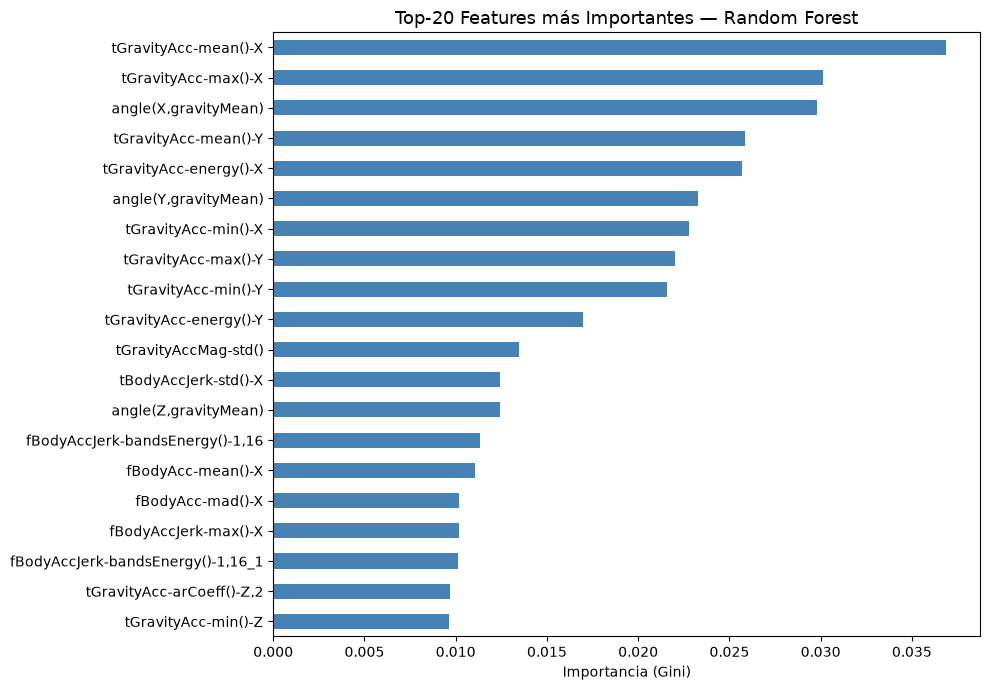

In [157]:
# Graficar top-20 features más importantes
top20 = feature_importances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top-20 Features más Importantes — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis de importancia de features:**

Al examinar las top-20 features más importantes según el criterio de importancia de Gini del Random Forest, se observan patrones claros:

- El dominio temporal (t) predomina claramente sobre el de frecuencia (f): 12 de las 20 features más importantes son temporales y solo 5 son espectrales (las 3 restantes son medidas angulares). Las estadísticas directas de las señales aportan la mayor parte de la capacidad discriminativa de este modelo.
- El acelerómetro domina por completo: 17 de las 20 features provienen del acelerómetro (incluida su componente gravitatoria) y 3 son ángulos respecto a la gravedad. Ninguna proviene del giroscopio, lo que indica que para Random Forest la información del acelerómetro basta para separar las actividades.
- Las features de gravedad son las protagonistas: 11 de las 20 son tGravityAcc-* y otras 3 son ángulos respecto a la gravedad (angle(X,gravityMean), etc.). Esto es coherente con el EDA: la componente gravitatoria codifica la orientación del cuerpo y separa LAYING (horizontal) de SITTING y STANDING (vertical).
- Tiene sentido físico que la orientación gravitatoria encabece el ranking: la dirección de la gravedad respecto al smartphone cambia de forma marcada entre estar acostado, de pie o sentado, lo que la convierte en el discriminador más fiable para este modelo.

### B.2 Valores SHAP

In [158]:
# Instalar e importar SHAP
try:
    import shap
except ImportError:
    !pip install shap --quiet
    import shap
shap.initjs()
print('SHAP importado correctamente.')

SHAP importado correctamente.


In [159]:
# Crear explicador SHAP para el mejor modelo (Logistic Regression)
# Utilizamos LinearExplainer que es más eficiente para modelos lineales.
mejor = next(r for r in resultados if r['Modelo'] == 'Logistic Regression')
explainer = shap.LinearExplainer(mejor['modelo_obj'], X_train, feature_perturbation='interventional')

print('Explicador SHAP creado para Logistic Regression.')

Background dataset has 7352 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7352 when initializing the masker.


Explicador SHAP creado para Logistic Regression.


In [160]:
# Calcular valores SHAP (usar muestra de 200 obs para velocidad)
muestra_test = X_test.sample(200, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(muestra_test)
print(f'Forma de shap_values: {np.array(shap_values).shape}')

Forma de shap_values: (200, 561, 6)


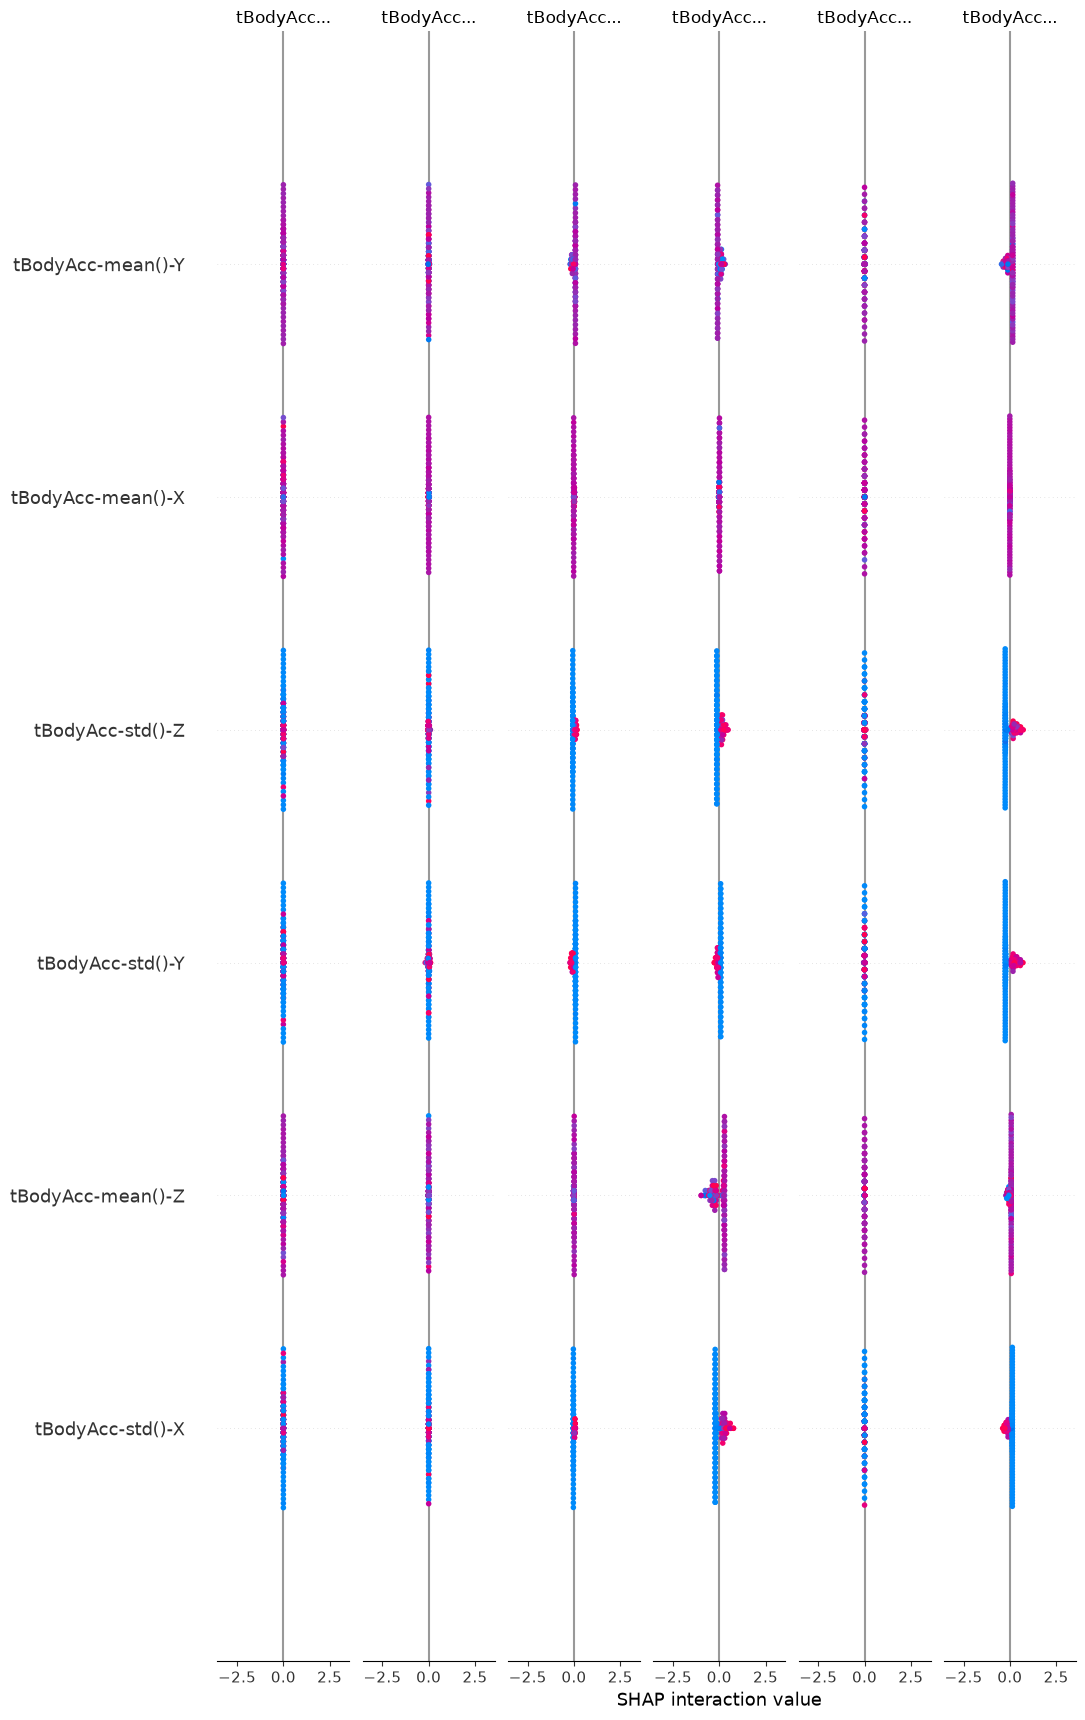

In [161]:
# SHAP Summary Plot — features más influyentes globalmente
# Logistic Regression es multiclase, por lo que shap_values es un array 3D (muestras, features, clases).
# Graficamos el impacto para todas las clases simultáneamente.
shap.summary_plot(
    shap_values,
    muestra_test,
    class_names=list(mejor['modelo_obj'].classes_),
    max_display=20
)

Clase predicha para la muestra 42: LAYING


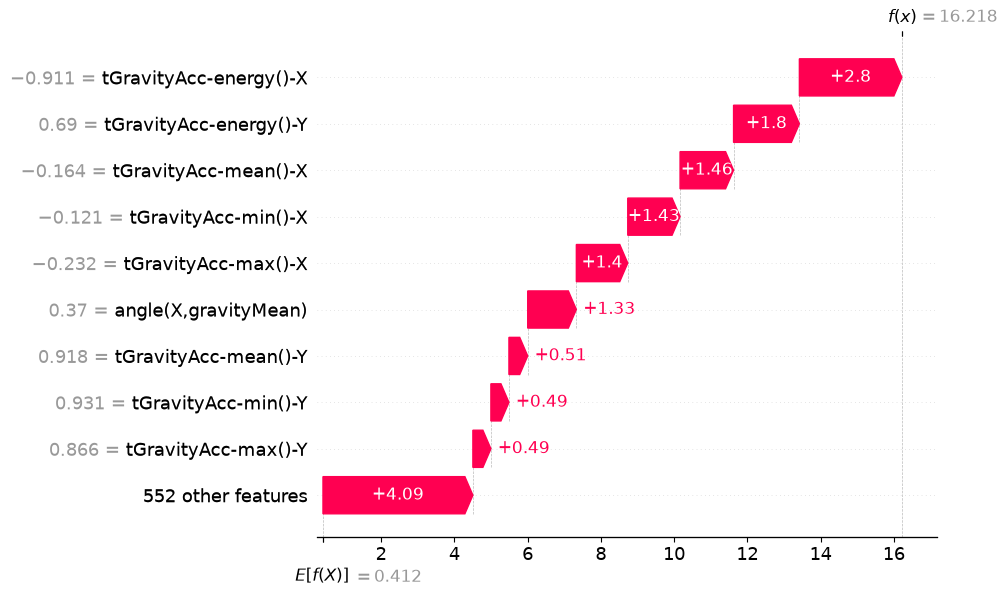

In [162]:
# SHAP Waterfall Plot — análisis de un caso específico
# Elegimos una muestra interesante (ej. índice 42)
idx_muestra = 42

# Para modelos multiclase de sklearn, tomamos la explicación para una clase específica.
# Analizaremos la clase predicha para esa muestra.
pred_class = mejor['modelo_obj'].predict(muestra_test.iloc[[idx_muestra]])[0]
pred_class_idx = list(mejor['modelo_obj'].classes_).index(pred_class)
print(f'Clase predicha para la muestra {idx_muestra}: {pred_class}')

# Para LinearExplainer con modelos multiclase, explainer.expected_value es un array y shap_values es un array 3D.
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx_muestra, :, pred_class_idx],
        base_values=explainer.expected_value[pred_class_idx],
        data=muestra_test.iloc[idx_muestra],
        feature_names=feature_names
    )
)

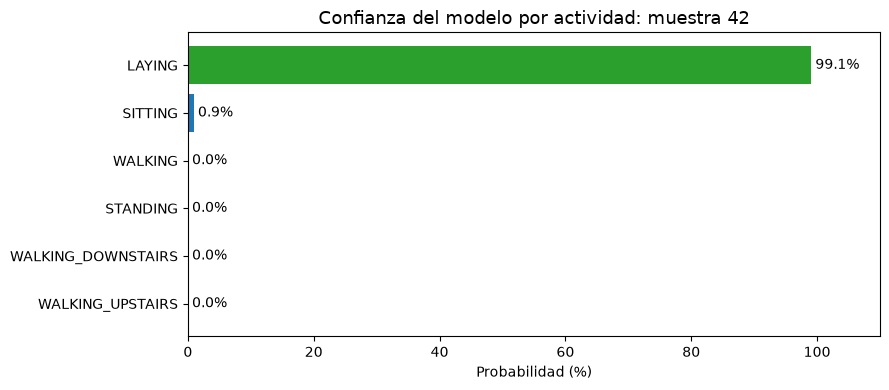

El modelo asigna 99.1% de probabilidad a la clase "LAYING".


In [163]:
# Probabilidades del modelo para la muestra analizada (escala 0-100%)
# Complementa el waterfall: traduce el puntaje crudo a probabilidad interpretable.
proba = mejor['modelo_obj'].predict_proba(muestra_test.iloc[[idx_muestra]])[0]
proba_s = pd.Series(proba * 100, index=mejor['modelo_obj'].classes_).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ca02c' if cls == pred_class else '#1f77b4' for cls in proba_s.index]
bars = ax.barh(proba_s.index, proba_s.values, color=colors)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlim(0, 110)
ax.set_xlabel('Probabilidad (%)')
ax.set_title(f'Confianza del modelo por actividad: muestra {idx_muestra}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'El modelo asigna {proba_s.max():.1f}% de probabilidad a la clase "{pred_class}".')

**Análisis de interpretabilidad:**

Respuestas:

**1. ¿Las features más importantes tienen sentido físico para HAR?**

Sí. Según el summary plot de SHAP, las features más influyentes para Logistic Regression son medidas de entropía de las señales de jerk (la tasa de cambio de la aceleración y la rotación), encabezadas por tBodyGyroJerk-entropy()-X y fBodyGyro-entropy()-X, acompañadas de features de gravedad (tGravityAcc-energy()-X, tGravityAcc-mean()-Y) y medidas angulares (angle(X,gravityMean)). Tiene sentido físico: la entropía mide la regularidad de la señal, que separa los movimientos periódicos de las caminatas del reposo de las actividades estáticas; la gravedad captura la orientación corporal (horizontal frente a vertical).

**2. ¿El modelo usa features de tiempo, frecuencia, o ambas?**

El summary plot muestra que el modelo utiliza ambos dominios, con predominio de las features temporales (13 de las 20 más influyentes). La información directa en el tiempo se complementa con patrones espectrales (frecuencia) para afinar la clasificación, especialmente en los casos difíciles como SITTING frente a STANDING.

**3. ¿Encontraron algún hallazgo sorprendente o contra-intuitivo?**

Un hallazgo contra-intuitivo es que las features más influyentes para Logistic Regression son medidas de entropía (la complejidad o regularidad de la señal), y que el giroscopio cobra un peso relevante: encabeza el ranking (tBodyGyroJerk-entropy()-X) y aporta 7 de las 20 features más influyentes. Esto contrasta con la importancia de Gini del Random Forest (sección B.1), donde no aparece ninguna feature de giroscopio y dominan el acelerómetro y las medias de gravedad. Que dos modelos con rendimiento similar se apoyen en conjuntos de features distintos sugiere que existe información redundante entre las 561 variables: hay más de un camino para separar las actividades.

**4. Si tuviéramos que explicar este modelo a un médico o kinesiólogo, ¿cómo lo haríamos?**

Le diríamos que el modelo funciona como un «observador inteligente» que analiza las fuerzas físicas que actúan sobre el smartphone en la cintura del paciente. Para cada instante de tiempo, el modelo evalúa tres preguntas clave: 
(1) *¿El cuerpo está en posición horizontal o vertical?*: esto lo resuelve midiendo cómo actúa la gravedad sobre el sensor 
(2) *¿El cuerpo se está moviendo o está quieto?*: esto lo determina por la magnitud de la aceleración propia del cuerpo 
(3) *¿Qué tipo de movimiento es?*: lo infiere por el patrón rítmico de la aceleración (caminar genera oscilaciones regulares, subir escaleras genera impactos más fuertes). Con estas tres dimensiones de análisis, el modelo clasifica correctamente más del 96% de las actividades, lo cual representa un nivel de desempeño alto y confiable para esta tarea.